<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Prediction_of_Single_Atom_Transistor_Dynamics_with_KWANT_CuPy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

```
Single-atom transistor model
├── P donor in Si
│   ├── screened Coulomb donor potential
│   ├── anisotropic Si effective masses
│   └── spatially varying gate coupling
├── open quantum transport
│   ├── Kwant semi-infinite source/drain leads
│   ├── Kwant lead self-energies
│   ├── sparse Caroli NEGF transmission
│   └── finite-T Landauer conductance
├── adaptive numerical path
│   ├── Hamiltonian adjacency graph
│   ├── reverse-Cuthill-McKee ordering
│   ├── SciPy sparse LU for smaller systems
│   └── CuPy CUDA sparse solve above threshold
└── outputs
    ├── 300 K transfer sweep
    ├── 4 K transfer sweep
    ├── 1.7 K transfer sweep
    ├── 10 mK transfer sweep
    ├── electrostatic-potential heatmap
    ├── Fermi-level LDOS heatmap
    ├── energy-gate transmission heatmap
    ├── 1D transmission spectrum
    └── PyVista 3D device rendering

In [6]:
"""This script initializes Conda in the Colab environment."""

!pip install -q condacolab
import condacolab
condacolab.install()

"""This script installs the target scientific libraries via Conda and uv."""

# Control Knobs
CONDA_PACKAGES = [
    "kwant",
    "numpy",
    "scipy",
    "matplotlib"
]

PIP_PACKAGES = [
    "tinyarray>=1.2.4",
    "cupy-cuda12x",
    "networkx",
    "pyvista"
]

!conda install -y -q -c conda-forge {" ".join(CONDA_PACKAGES)}
!python -m pip -q install uv
!uv pip install --system {" ".join(PIP_PACKAGES)}

✨🍰✨ Everything looks OK!
Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.

Using Python 3.13.13 environment at: /usr/local
Checked 4 packages in 5ms


Device sites: 969
Hopping energies: tx=0.5570 eV, ty=0.1080 eV
Adjacency: mean degree=3.856, max degree=4
Sparse bandwidth: 19 -> 19
Selected transport backend: GPU
Active compute device: NVIDIA L4
Charging-energy reference: 47.0 meV
Equivalent central gate spacing U/alpha: 0.370 V
NEGF verification | Kwant=0.00021142122, custom (GPU)=0.00021142122, scaled error=6.032e-13
Transfer sweep: T = 300 K [Backend: GPU]
Transfer sweep: T = 4 K [Backend: GPU]
Transfer sweep: T = 1.7 K [Backend: GPU]
Transfer sweep: T = 0.01 K [Backend: GPU]
Selected LDOS/spectrum operating gate from the coldest sweep: 0.4563 V


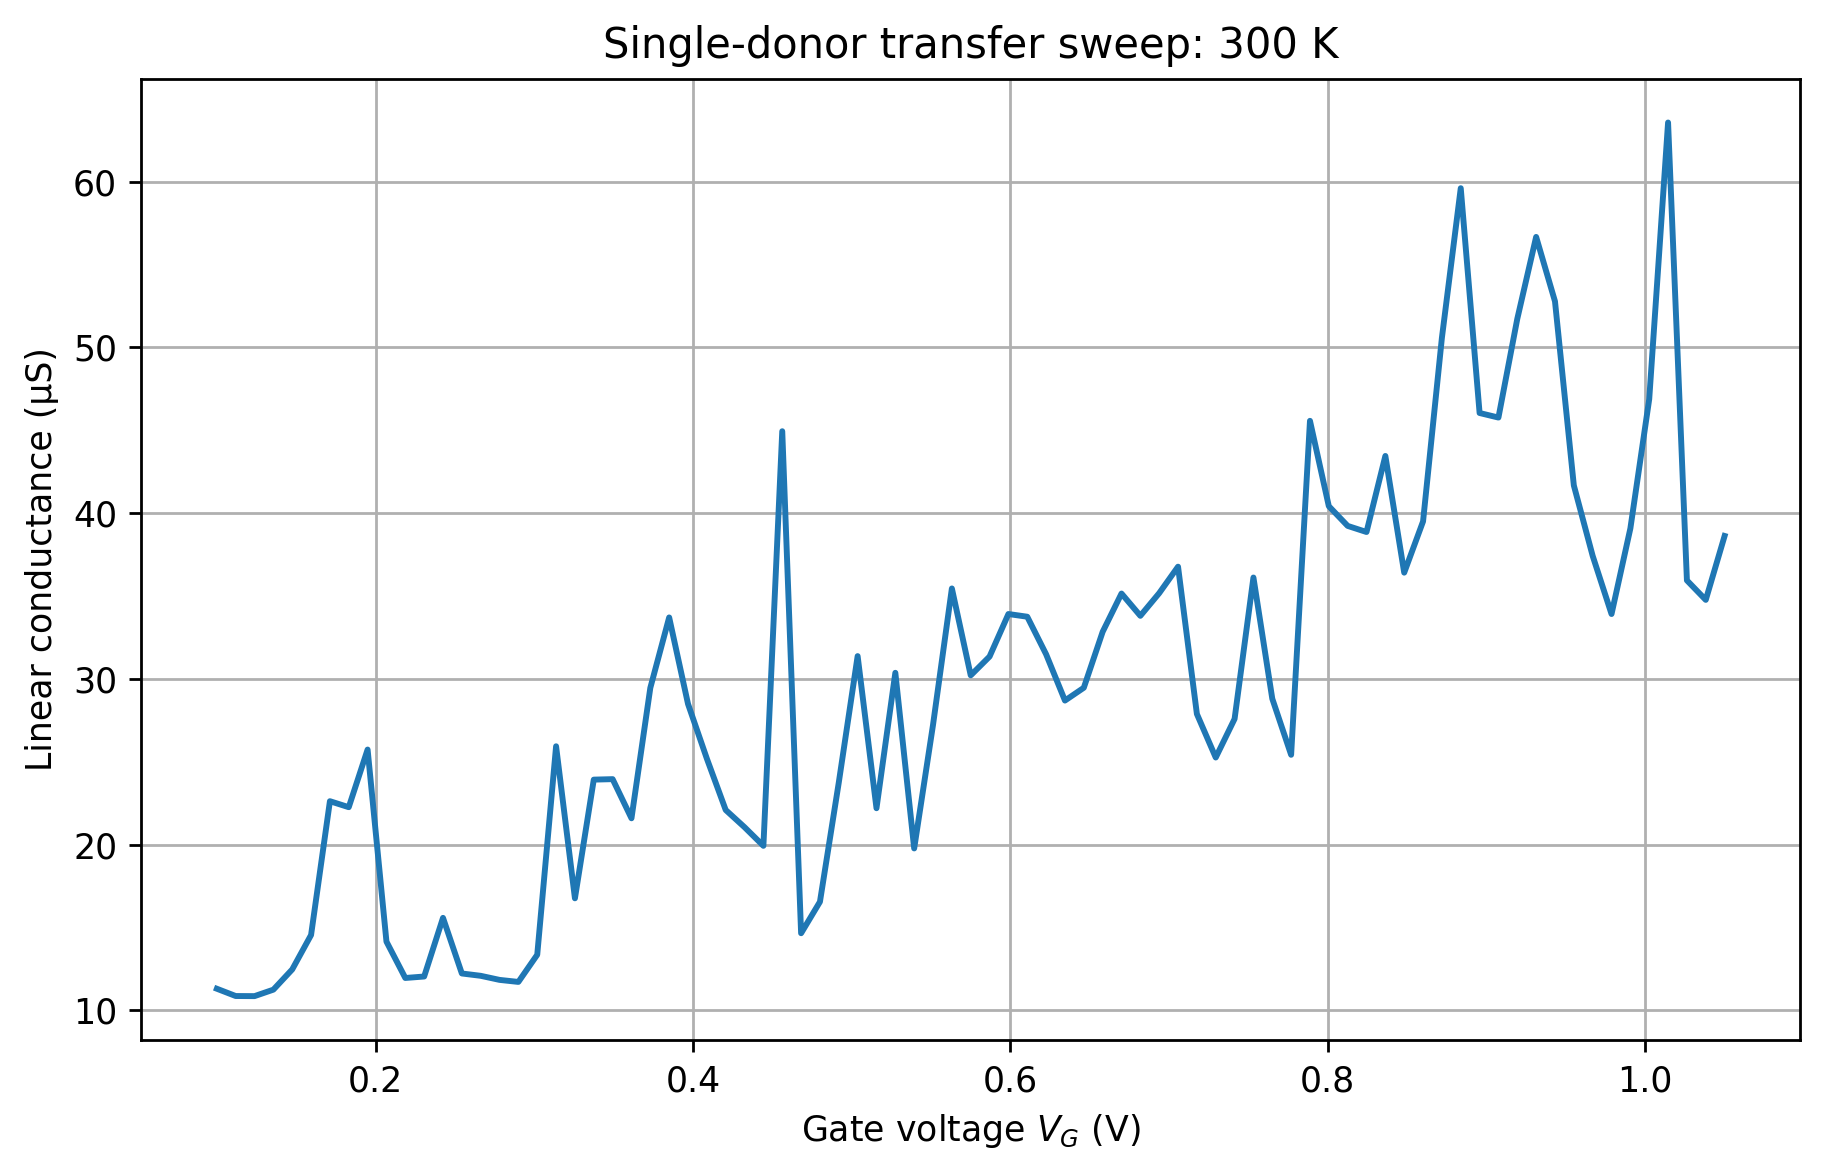

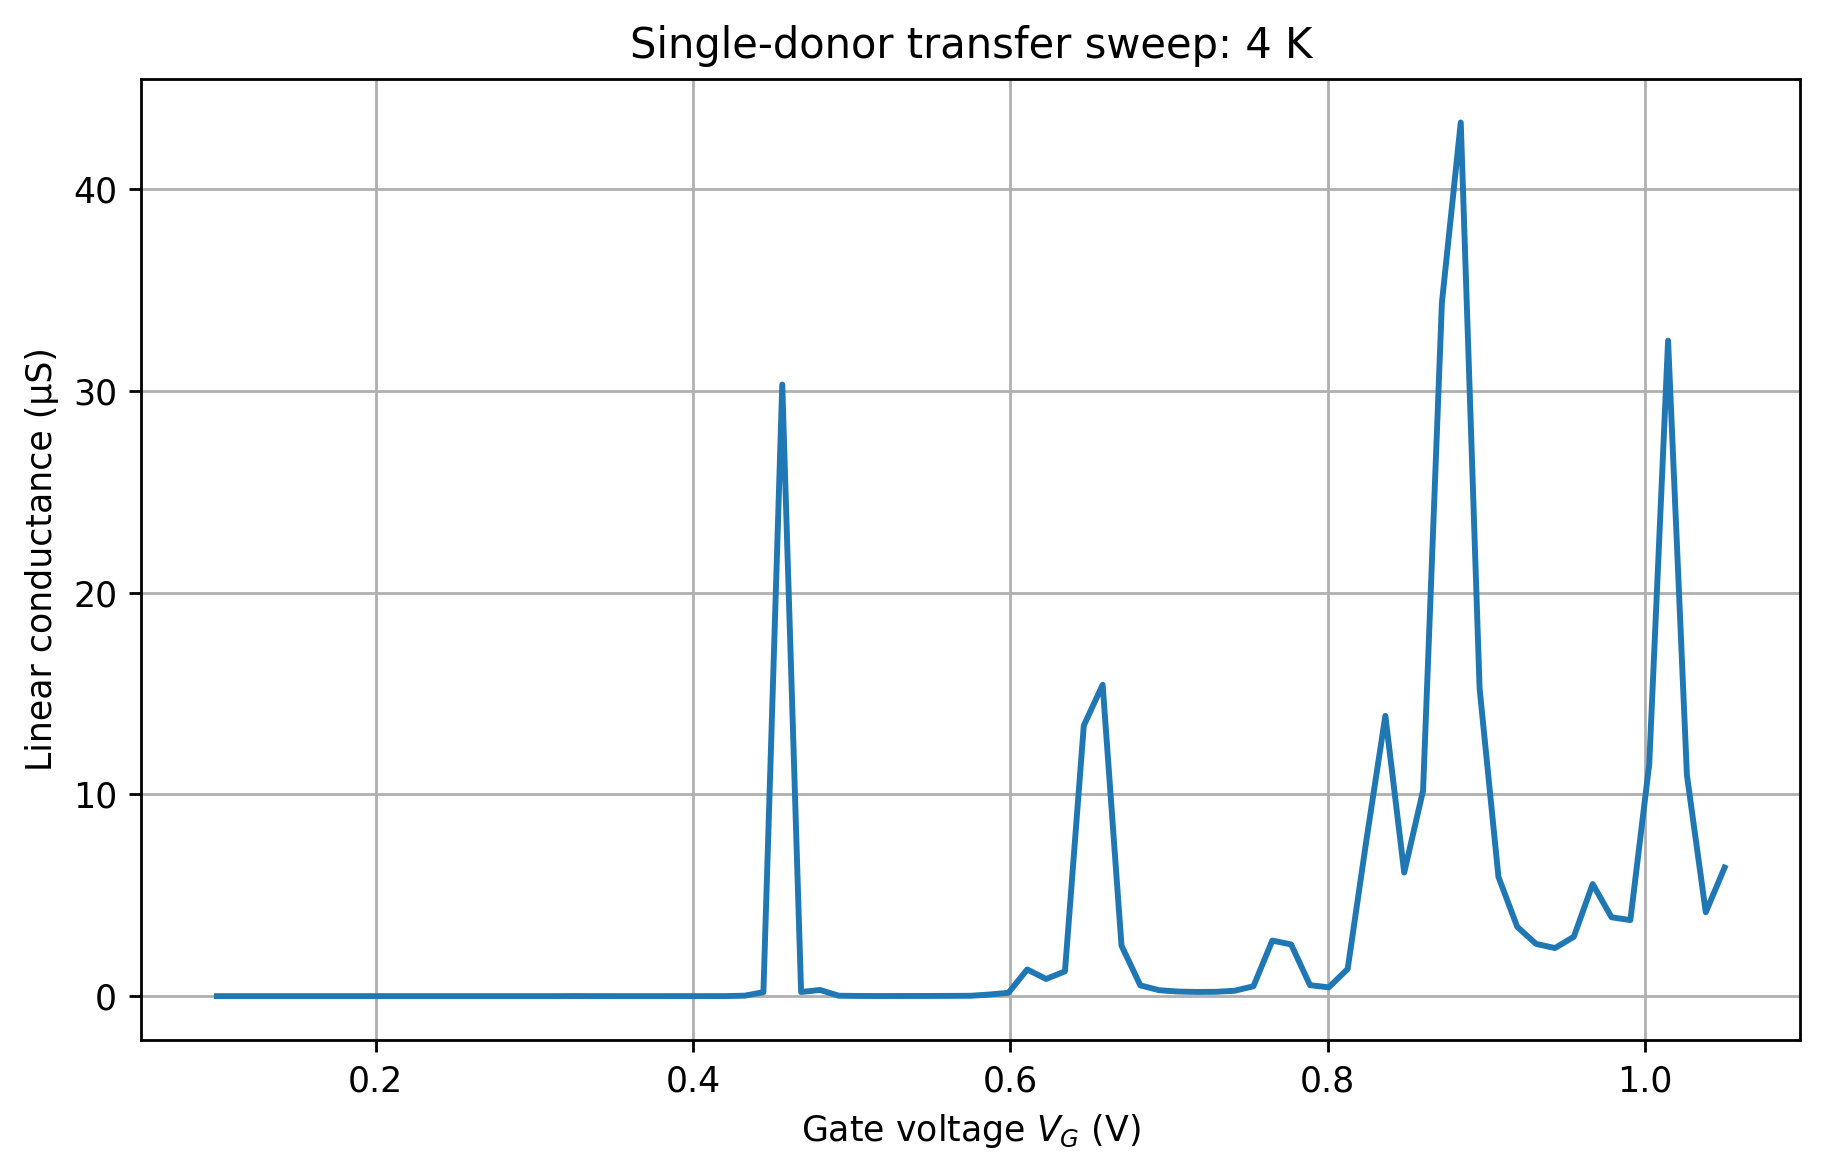

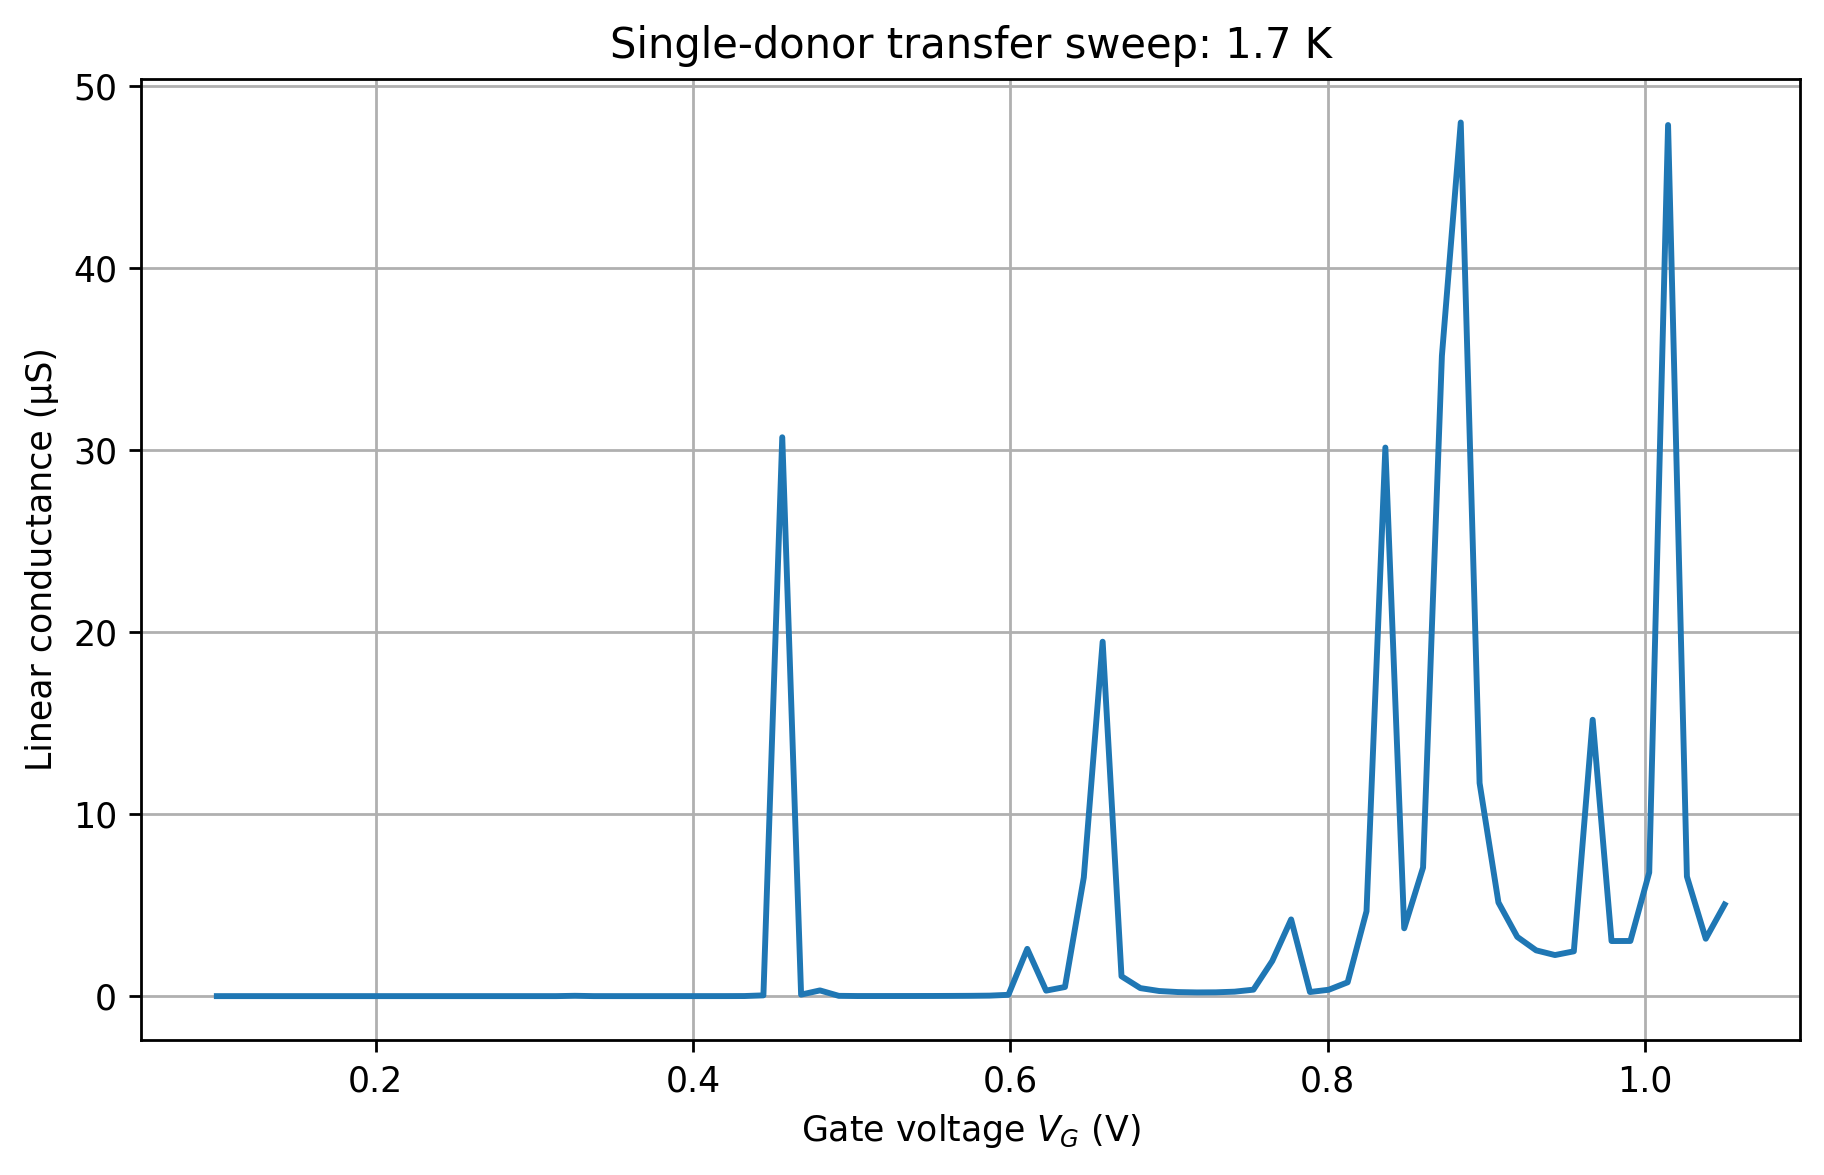

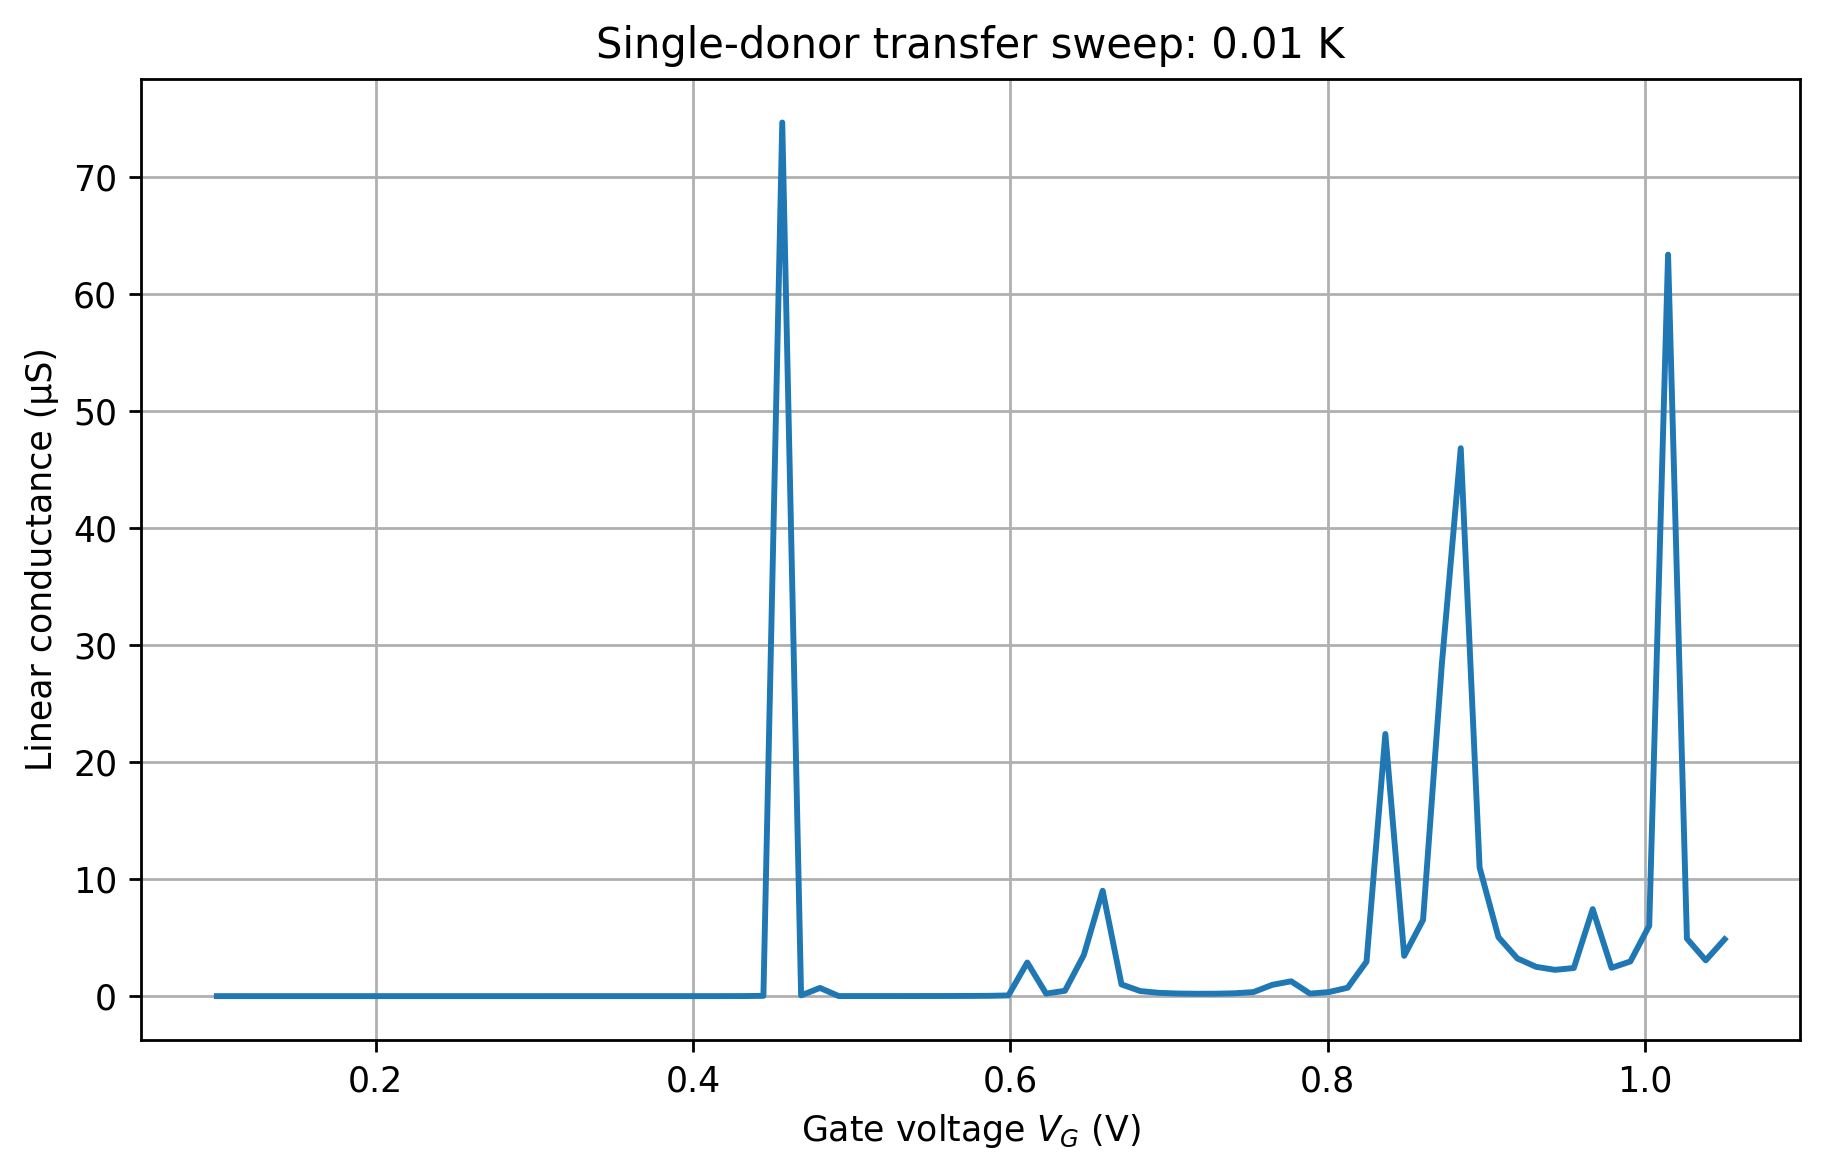

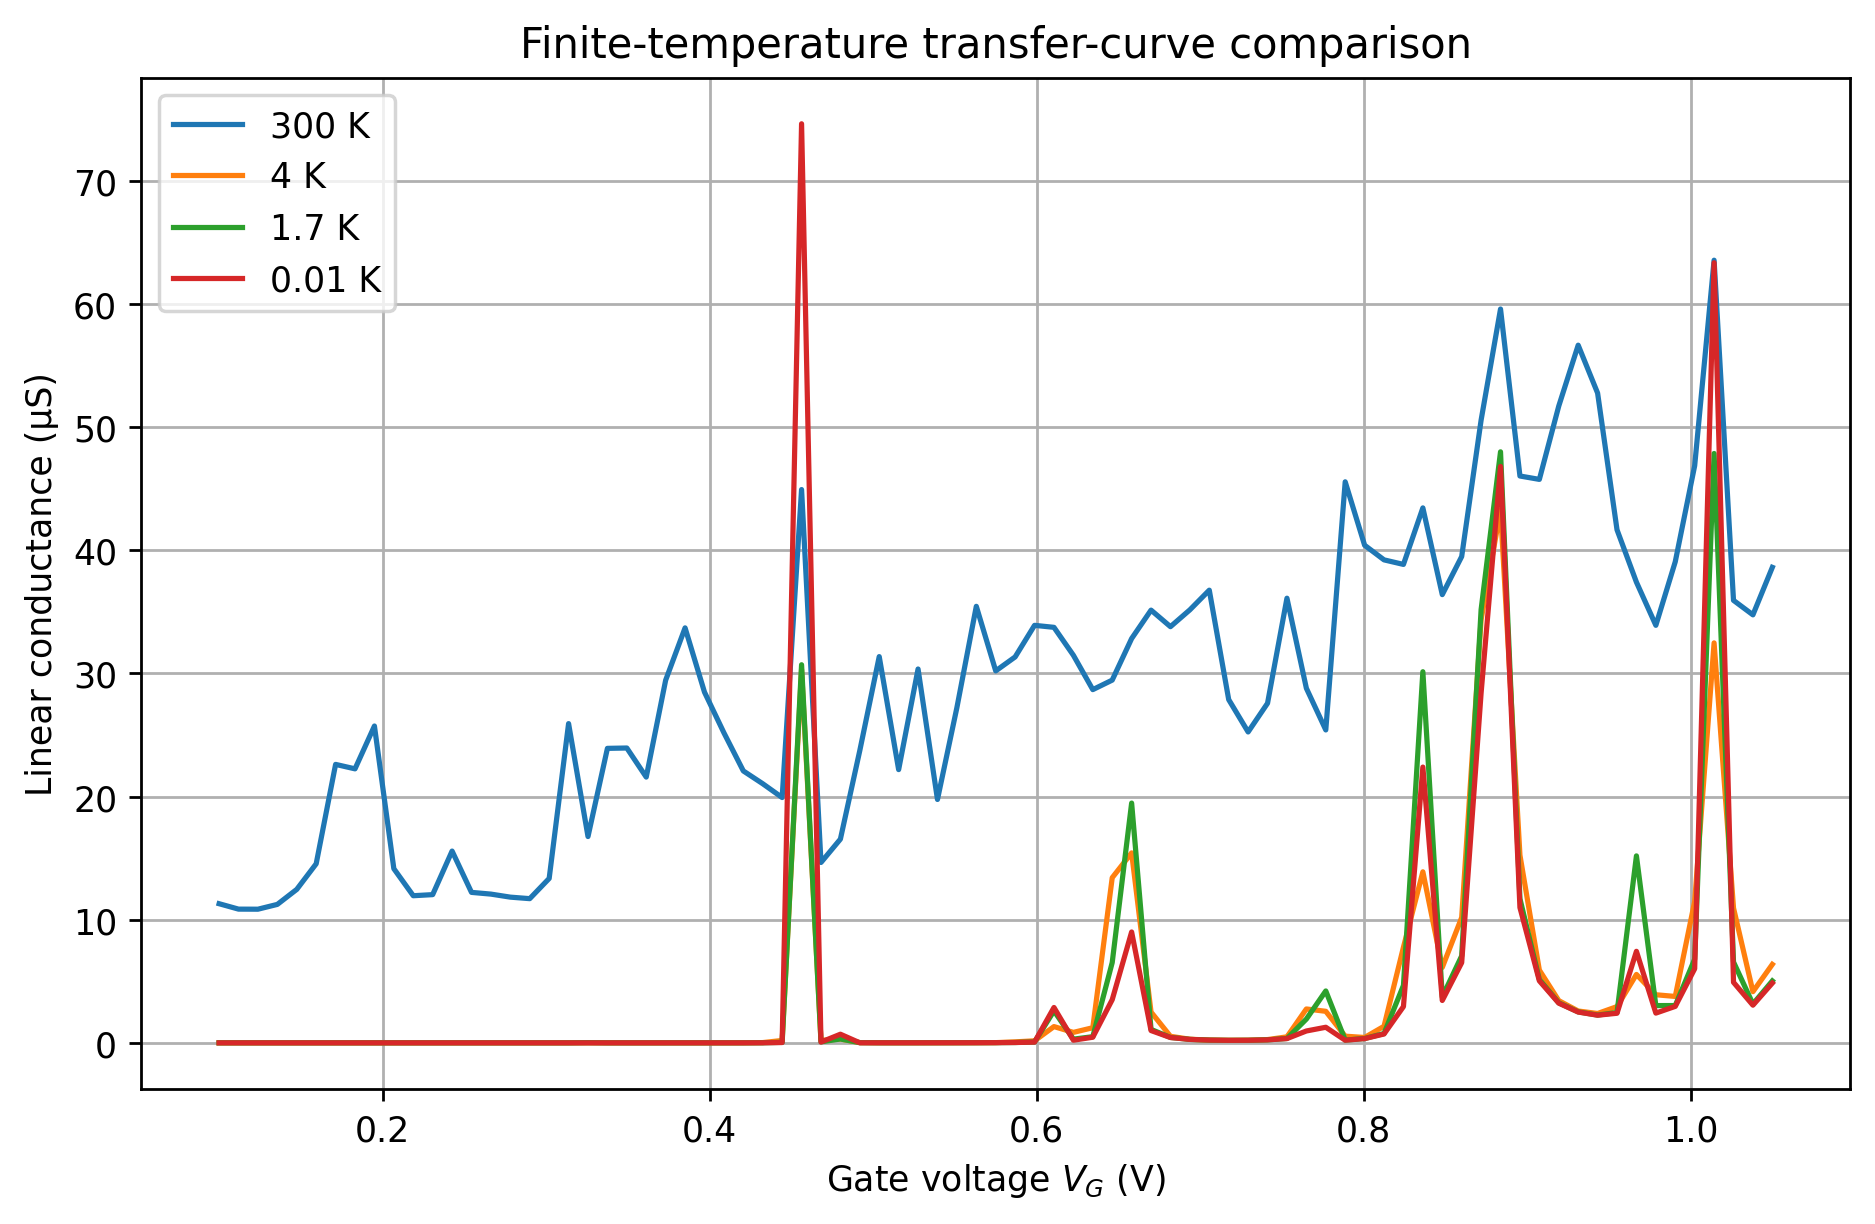

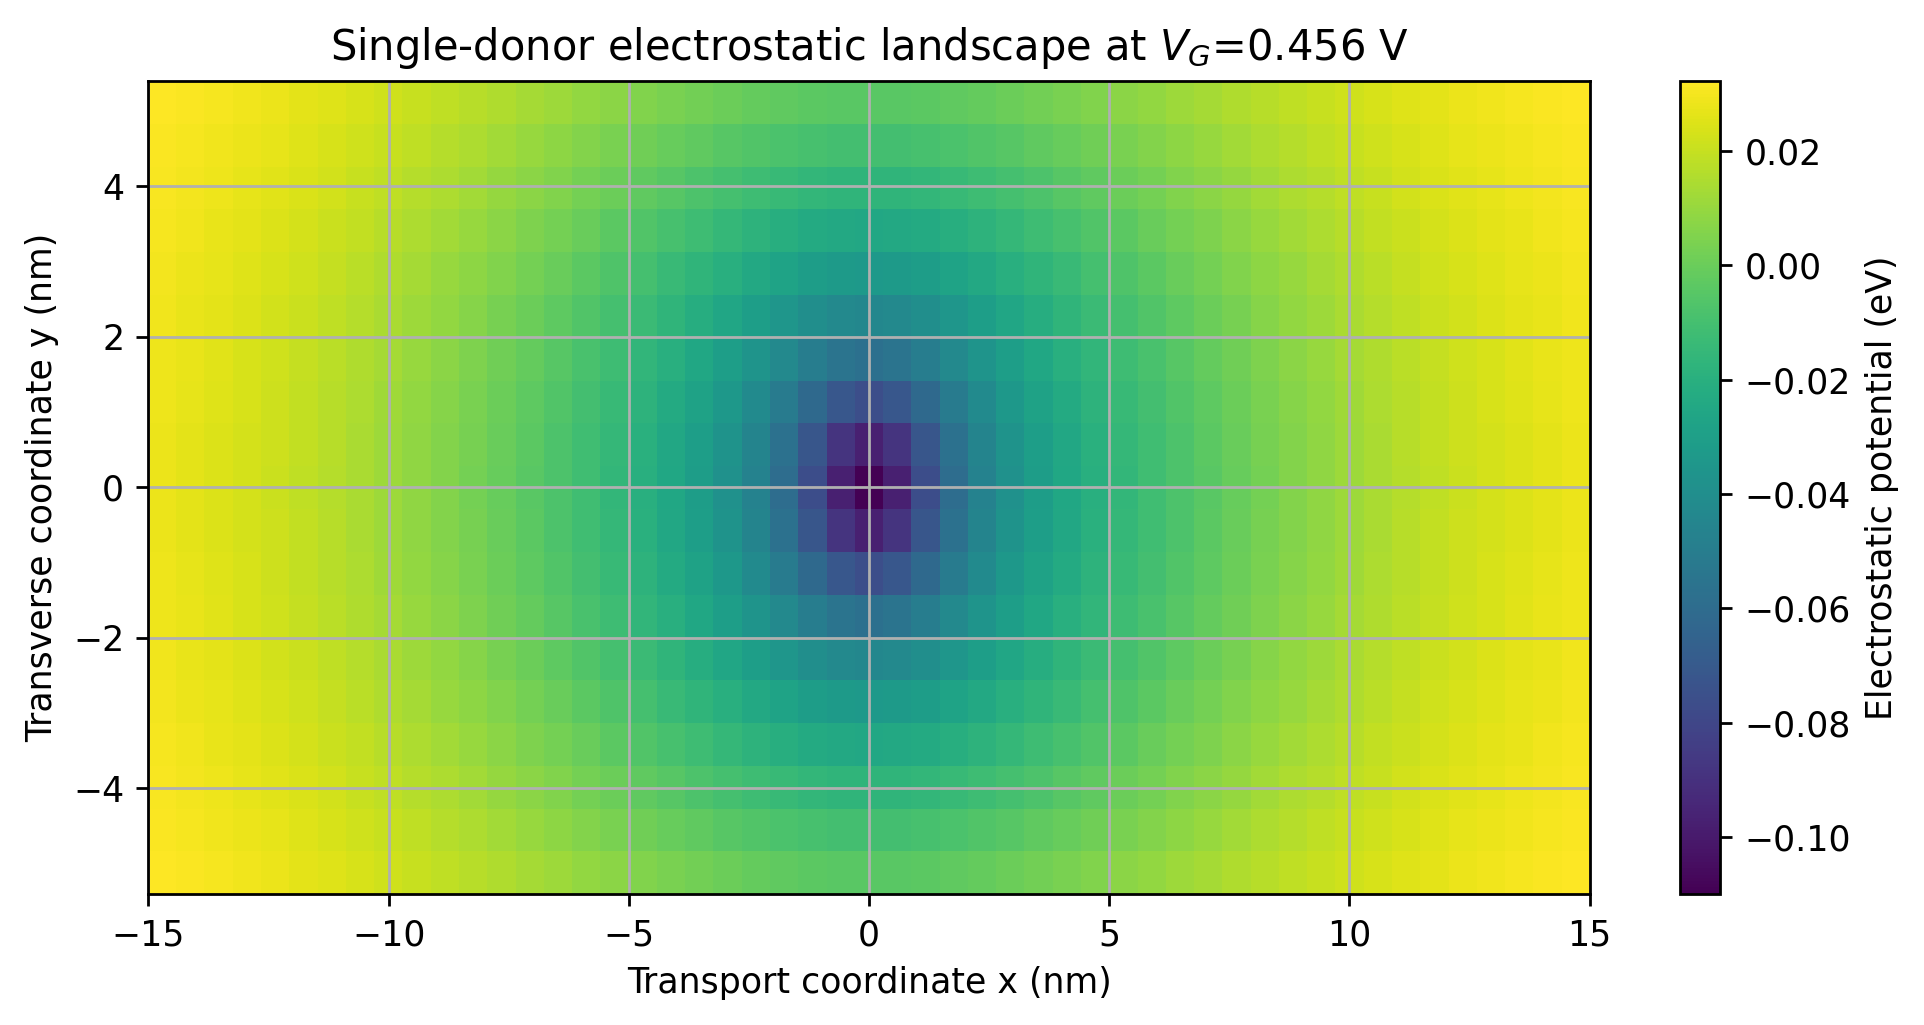

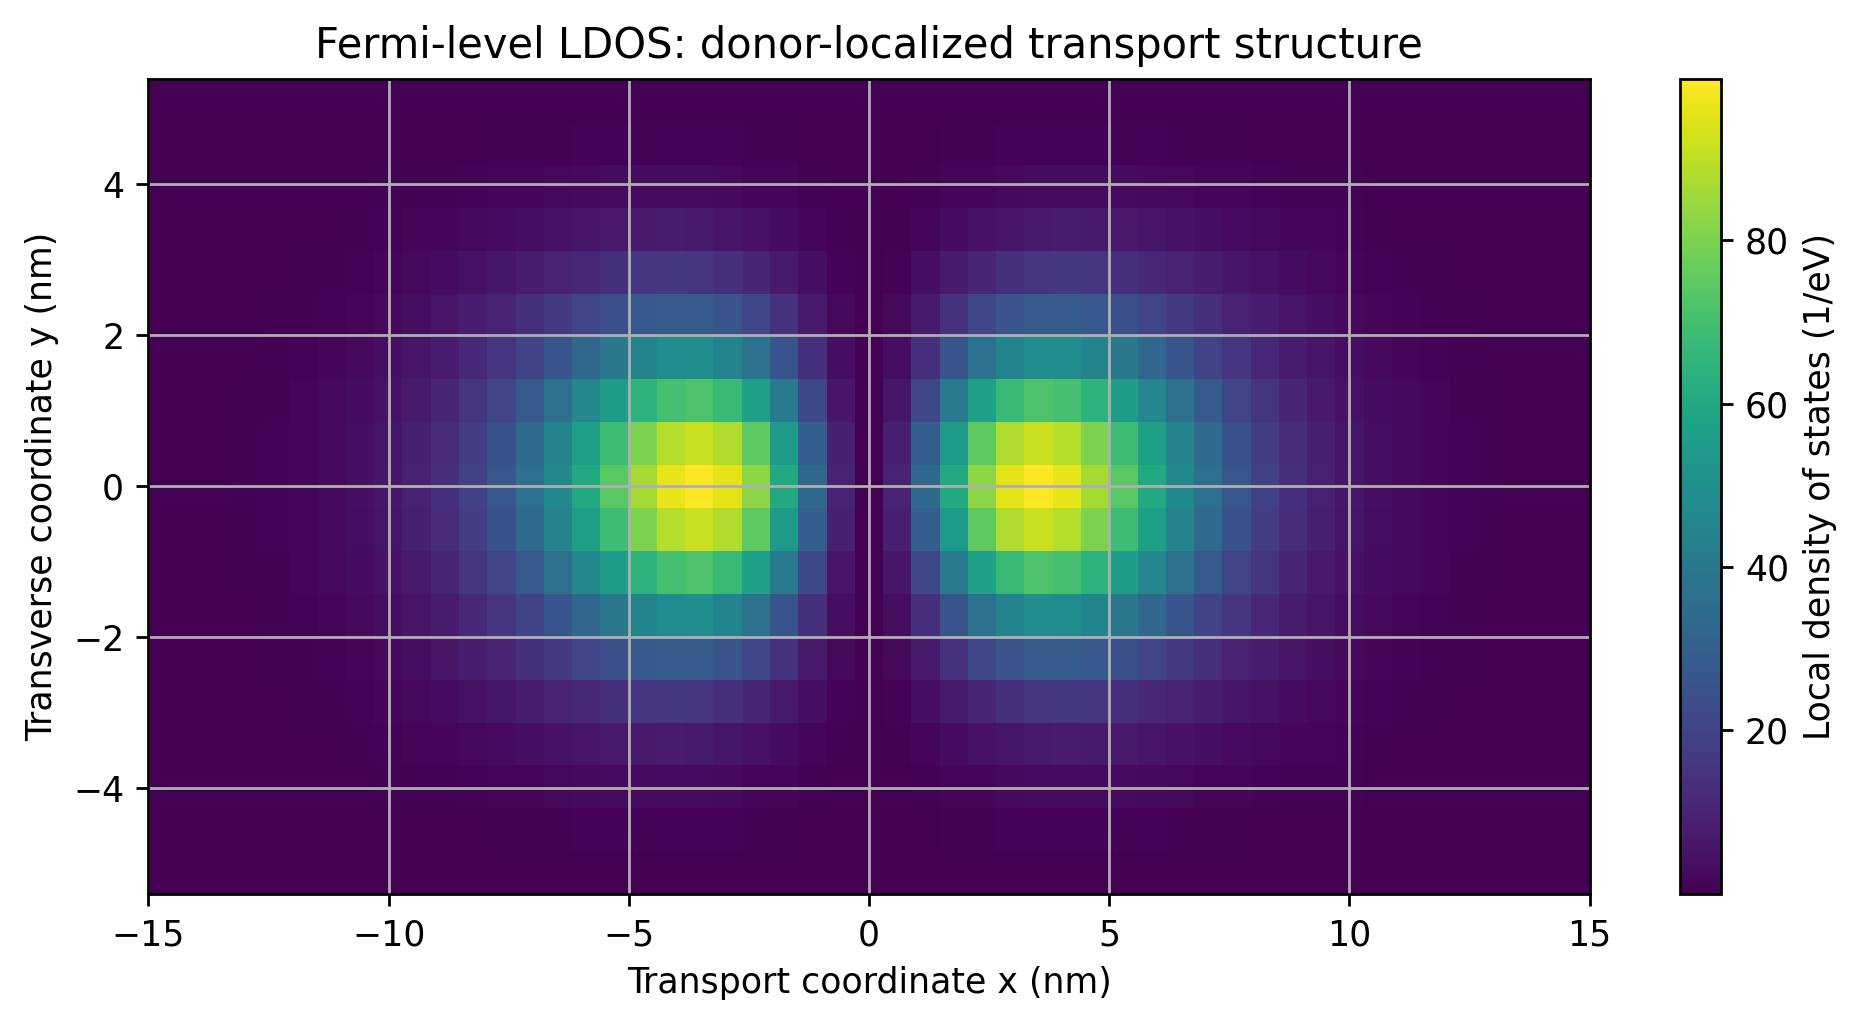

Computing transmission heatmap [Backend: GPU].


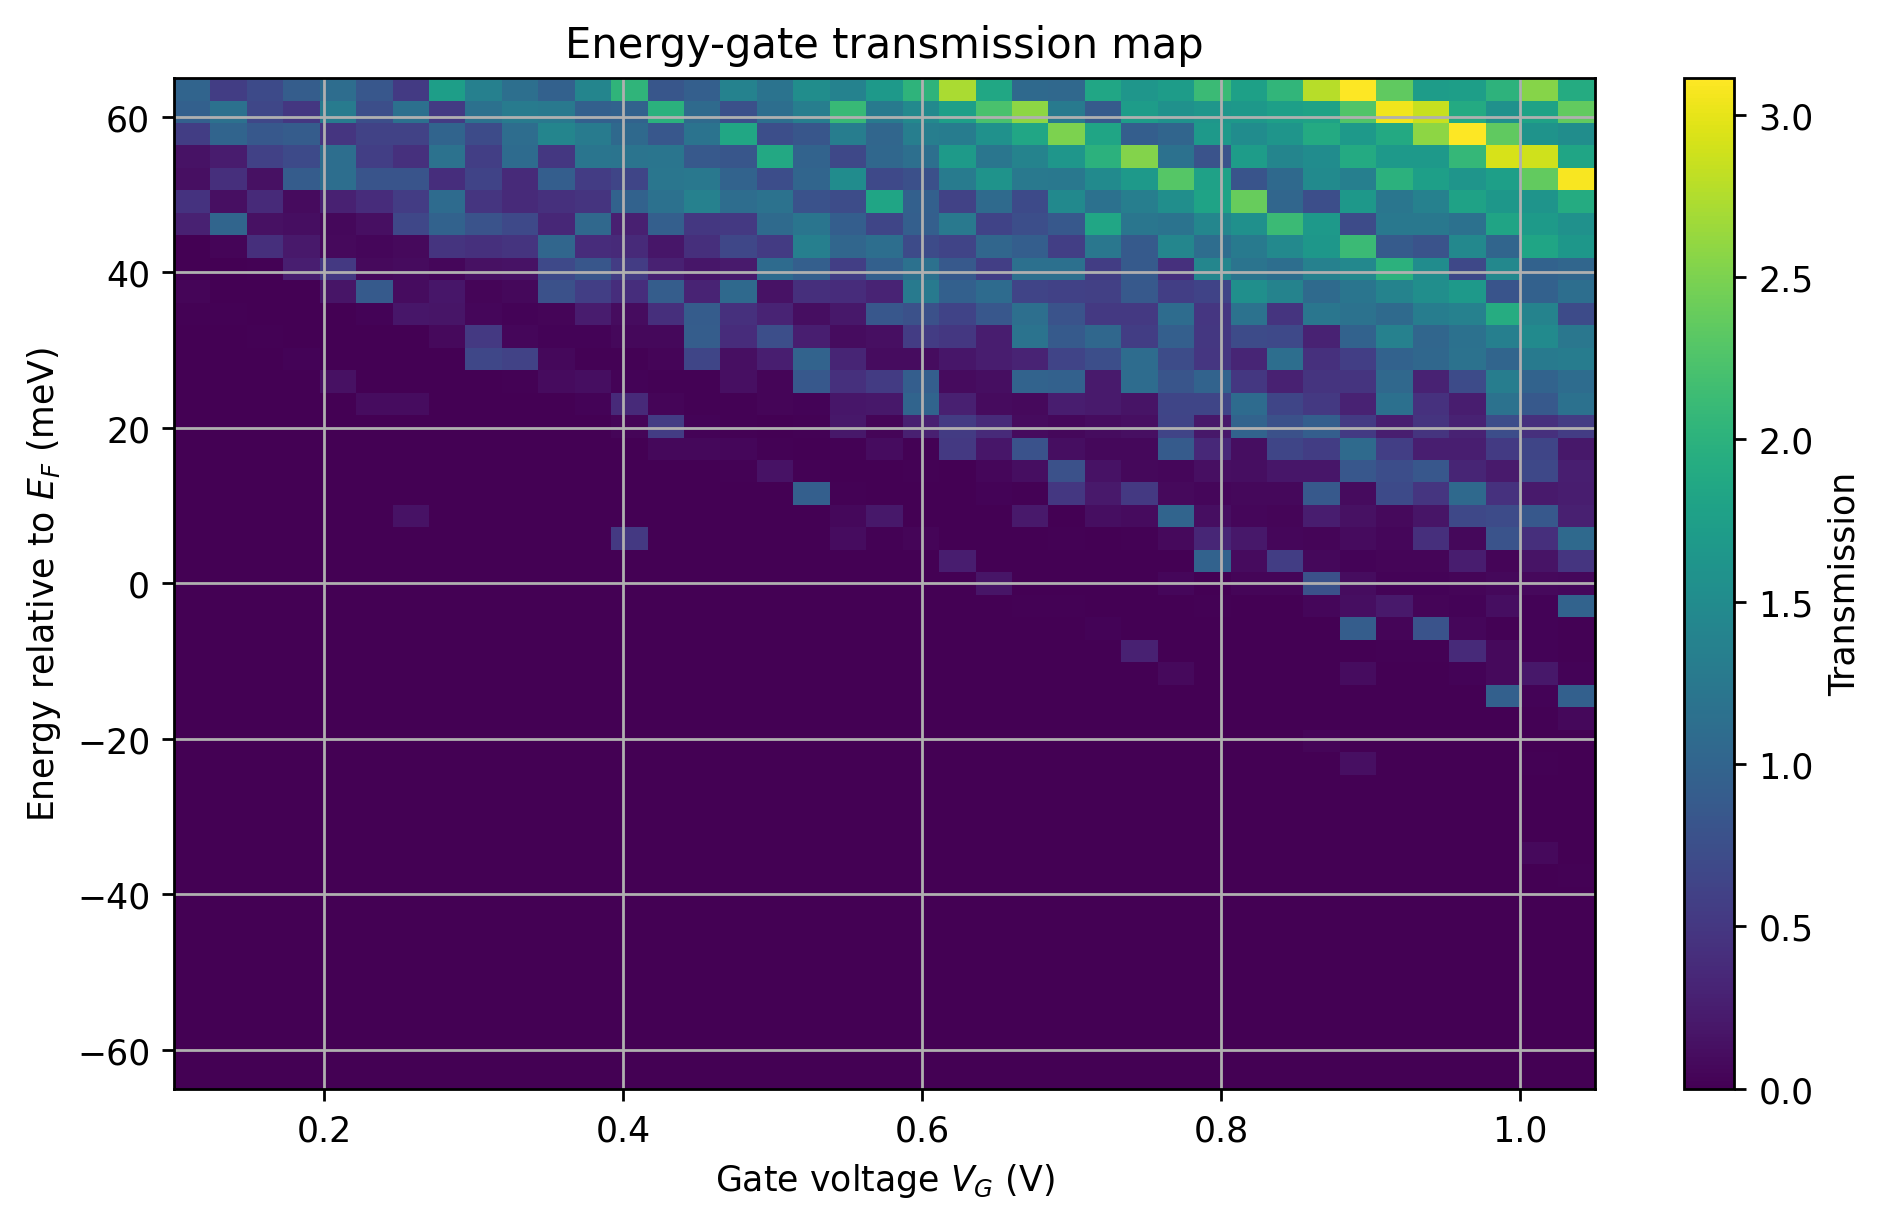

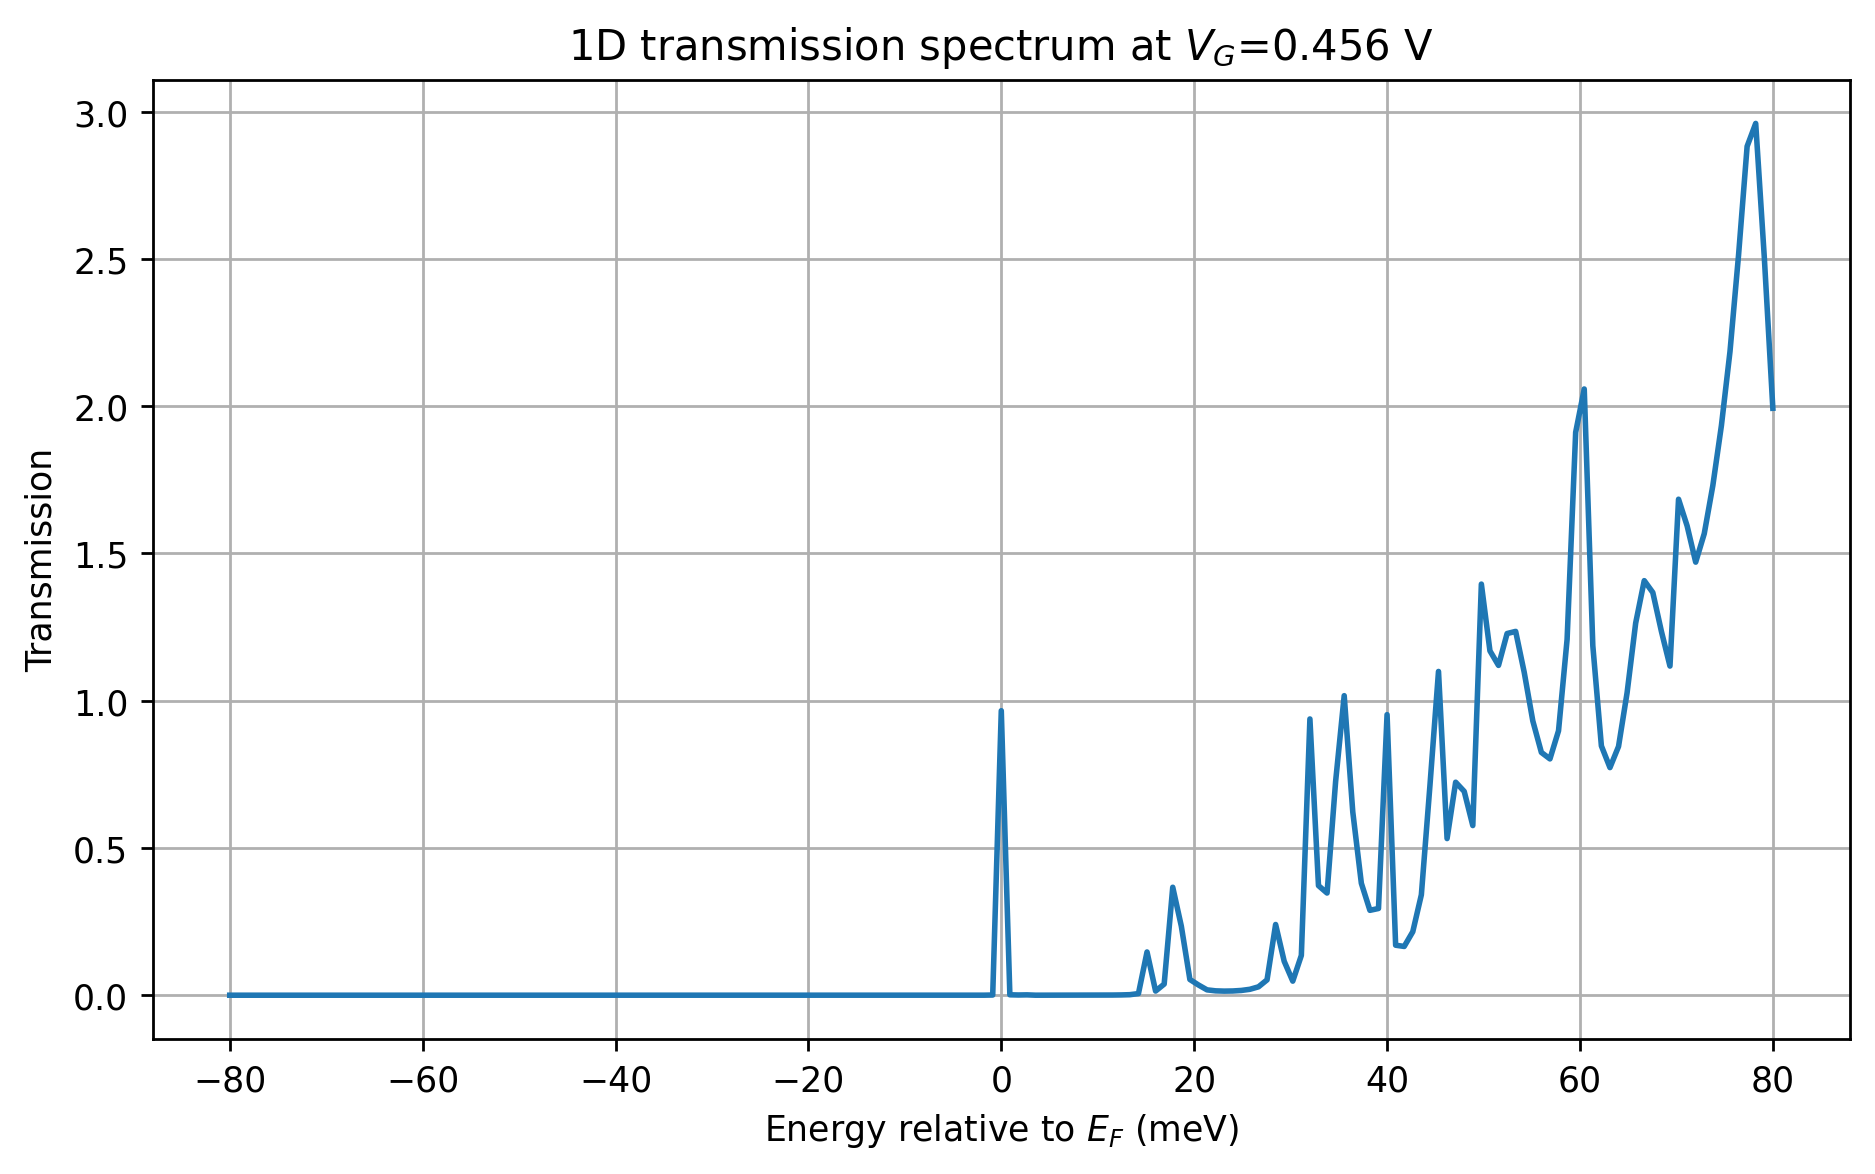

Completed in 140.3 s on NVIDIA L4.


/tmp/ipykernel_1501/3224411610.py:1061: UserWarning: PyVista is unavailable; geometry rendering skipped.
  warnings.warn("PyVista is unavailable; geometry rendering skipped.")


In [7]:
"""This script simulates a phosphorus single-atom transistor on a GPU with Kwant and NEGF.

Scientific scope
----------------
This script represents a single substitutional phosphorus (P) donor in a
laterally confined silicon (Si) channel using an anisotropic effective-mass
finite-difference Hamiltonian. Kwant defines the open device and computes the
semi-infinite lead self-energies. A custom Caroli Non-Equilibrium Green's
Function (NEGF) transport backend then evaluates transmission on the Graphics
Processing Unit (GPU) using CuPy sparse Lower-Upper (LU) factorization.

The model includes:
    * A softened screened Coulomb potential for one P donor.
    * Spatially nonuniform gate coupling.
    * Anisotropic silicon effective masses.
    * Open source and drain leads.
    * Finite-temperature linear-response Landauer conductance.
    * Separate transfer sweeps at 300 K, 4 K, 1.7 K, and 10 mK.
    * Transmission-energy/gate and Local Density of States (LDOS) heatmaps.
    * A One-Dimensional (1D) transmission spectrum.
    * Reverse Cuthill-McKee (RCM) adjacency ordering for sparse matrices.
    * Resident GPU sparse matrix assembly and multi-column LU solving.
    * A Kwant scattering-matrix cross-check of the custom NEGF implementation.
    * An in-memory PyVista Three-Dimensional (3D) device rendering.
"""

from functools import lru_cache
import math
import time
from typing import Dict, List, Tuple, Union
import warnings

import kwant
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy.constants as const
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.csgraph import connected_components
from scipy.sparse.csgraph import reverse_cuthill_mckee

try:
    import cupy as cp
    import cupyx.scipy.sparse as cpx_sp
    import cupyx.scipy.sparse.linalg as cpx_spla

    CUPY_IMPORTED = True
except Exception:
    cp = None
    cpx_sp = None
    cpx_spla = None
    CUPY_IMPORTED = False

try:
    import pyvista as pv

    PYVISTA_IMPORTED = True
except Exception:
    pv = None
    PYVISTA_IMPORTED = False


# ==============================================================================
# Control Knobs: Physical Model
# ==============================================================================

GRID_NM: float = 0.60
CHANNEL_LENGTH_NM: float = 30.0
CHANNEL_WIDTH_NM: float = 11.0

MASS_X_ME: float = 0.19
MASS_Y_ME: float = 0.98
SILICON_RELATIVE_PERMITTIVITY: float = 11.7

DONOR_X_NM: float = 0.0
DONOR_Y_NM: float = 0.0
DONOR_SOFTENING_NM: float = 1.15
DONOR_SCREEN_SCALE: float = 1.0

CHANNEL_OFFSET_EV: float = 0.055
LEAD_OFFSET_EV: float = -0.30
FERMI_ENERGY_EV: float = 0.0

GATE_LEVER_ARM_EV_PER_V: float = 0.127
GATE_SIGMA_X_NM: float = 8.0
GATE_SIGMA_Y_NM: float = 5.0
GATE_BACKGROUND_COUPLING: float = 0.18

REFERENCE_CHARGING_ENERGY_EV: float = 0.047
SPIN_DEGENERACY: float = 2.0


# ==============================================================================
# Control Knobs: Transfer Sweeps and Spectra
# ==============================================================================

GATE_MIN_V: float = 0.10
GATE_MAX_V: float = 1.05
N_GATE: int = 81

TEMPERATURES_K: Tuple[float, ...] = (300.0, 4.0, 1.7, 0.010)
THERMAL_QUADRATURE_POINTS: int = 17
THERMAL_X_MAX: float = 9.0

TRANSMISSION_MAP_GATE_POINTS: int = 39
TRANSMISSION_MAP_ENERGY_POINTS: int = 45
TRANSMISSION_MAP_E_MIN_EV: float = -0.065
TRANSMISSION_MAP_E_MAX_EV: float = 0.065

SPECTRUM_POINTS: int = 181
SPECTRUM_E_MIN_EV: float = -0.080
SPECTRUM_E_MAX_EV: float = 0.080


# ==============================================================================
# Control Knobs: Sparse Solver, GPU Selection, and Adjacency
# ==============================================================================

USE_GPU: Union[bool, str] = True  # True, False, or "auto"
GPU_MIN_SITES: int = 500
GPU_DTYPE = np.complex128
CPU_DTYPE = np.complex128

USE_RCM_ORDERING: bool = True
ETA_EV: float = 1.0e-10
TRANSMISSION_NEGATIVE_TOL: float = 1.0e-8

VERIFY_NEGF_WITH_KWANT: bool = True
VERIFY_RELATIVE_TOL: float = 5.0e-5


# ==============================================================================
# Control Knobs: Optional Grid Fidelity Audit
# ==============================================================================

RUN_GRID_CONVERGENCE_AUDIT: bool = False
AUDIT_GRID_NM: Tuple[float, ...] = (0.85, 0.70, 0.60)
AUDIT_GATE_POINTS: int = 31
AUDIT_PEAK_TOLERANCE_V: float = 0.025


# ==============================================================================
# Control Knobs: In-Memory Visualization Settings
# ==============================================================================

PLOT_DPI: int = 250
RUN_PYVISTA: bool = True

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["font.weight"] = "normal"
plt.rcParams["axes.grid"] = True


# ==============================================================================
# Physical Constants
# ==============================================================================

EV_TO_J: float = const.e
KB_EV_K: float = const.Boltzmann / const.e
G_E2_OVER_H_SIEMENS: float = const.e**2 / const.h
COULOMB_EV_NM: float = (
    const.e**2 / (4.0 * math.pi * const.epsilon_0)
) / const.e * 1.0e9


def hopping_ev(mass_me: float, grid_nm: float) -> float:
    """Computes nearest-neighbor finite-difference hopping in electronvolts.

    Args:
        mass_me: Directional effective mass relative to the free electron mass.
        grid_nm: Finite-difference lattice spacing in nanometers.

    Returns:
        The nearest-neighbor hopping energy in electronvolts.
    """
    grid_m = grid_nm * 1.0e-9
    energy_j = const.hbar**2 / (2.0 * mass_me * const.m_e * grid_m**2)
    return float(energy_j / const.e)


def gate_profile(x_nm: float, y_nm: float) -> float:
    """Computes the dimensionless local electrostatic gate-coupling profile.

    Args:
        x_nm: Longitudinal transport coordinate in nanometers.
        y_nm: Transverse confinement coordinate in nanometers.

    Returns:
        Dimensionless gate coupling factor at (x_nm, y_nm).
    """
    dx = (x_nm - DONOR_X_NM) / GATE_SIGMA_X_NM
    dy = (y_nm - DONOR_Y_NM) / GATE_SIGMA_Y_NM
    localized = math.exp(-0.5 * (dx * dx + dy * dy))
    return (
        GATE_BACKGROUND_COUPLING
        + (1.0 - GATE_BACKGROUND_COUPLING) * localized
    )


def donor_potential_ev(x_nm: float, y_nm: float) -> float:
    """Computes the softened screened Coulomb potential of one phosphorus donor.

    Args:
        x_nm: Longitudinal transport coordinate in nanometers.
        y_nm: Transverse confinement coordinate in nanometers.

    Returns:
        Screened attractive donor potential in electronvolts.
    """
    dx = x_nm - DONOR_X_NM
    dy = y_nm - DONOR_Y_NM
    radius_nm = math.sqrt(dx * dx + dy * dy + DONOR_SOFTENING_NM**2)
    return -(
        DONOR_SCREEN_SCALE
        * COULOMB_EV_NM
        / SILICON_RELATIVE_PERMITTIVITY
        / radius_nm
    )


def build_device(
    grid_nm: float = GRID_NM,
) -> Tuple[kwant.system.FiniteSystem, float, float]:
    """Builds and finalizes the anisotropic effective-mass donor transistor.

    Args:
        grid_nm: Finite-difference grid spacing in nanometers.

    Returns:
        A tuple containing the finalized Kwant system, longitudinal hopping tx,
        and transverse hopping ty.
    """
    tx = hopping_ev(MASS_X_ME, grid_nm)
    ty = hopping_ev(MASS_Y_ME, grid_nm)

    lat = kwant.lattice.square(a=grid_nm, norbs=1)
    syst = kwant.Builder()

    nx_half = int(round(CHANNEL_LENGTH_NM / (2.0 * grid_nm)))
    ny_half = int(round(CHANNEL_WIDTH_NM / (2.0 * grid_nm)))

    def scattering_onsite(site: kwant.builder.Site, vg: float) -> float:
        x_nm, y_nm = site.pos
        electrostatic = (
            CHANNEL_OFFSET_EV
            + donor_potential_ev(x_nm, y_nm)
            - GATE_LEVER_ARM_EV_PER_V * vg * gate_profile(x_nm, y_nm)
        )
        return 2.0 * tx + 2.0 * ty + electrostatic

    for i in range(-nx_half, nx_half + 1):
        for j in range(-ny_half, ny_half + 1):
            syst[lat(i, j)] = scattering_onsite

    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = -tx
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = -ty

    lead = kwant.Builder(kwant.TranslationalSymmetry((-grid_nm, 0.0)))

    def lead_onsite(site: kwant.builder.Site) -> float:
        del site
        return 2.0 * tx + 2.0 * ty + LEAD_OFFSET_EV

    for j in range(-ny_half, ny_half + 1):
        lead[lat(0, j)] = lead_onsite

    lead[kwant.builder.HoppingKind((1, 0), lat, lat)] = -tx
    lead[kwant.builder.HoppingKind((0, 1), lat, lat)] = -ty

    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())

    return syst.finalized(), tx, ty


def matrix_bandwidth(matrix: sp.spmatrix) -> int:
    """Computes the maximum sparse-matrix index displacement.

    Args:
        matrix: SciPy sparse matrix to inspect.

    Returns:
        Integer bandwidth of the sparse matrix.
    """
    rows, cols = matrix.nonzero()
    if len(rows) == 0:
        return 0
    return int(np.max(np.abs(rows - cols)))


def gpu_available() -> bool:
    """Checks whether a usable CUDA device is visible to CuPy.

    Returns:
        True if CuPy is imported and an NVIDIA CUDA device is accessible.
    """
    if not CUPY_IMPORTED:
        return False
    try:
        return bool(cp.cuda.is_available())
    except Exception:
        return False


def resolve_backend_preference(
    preference: Union[bool, str],
    n_sites: int,
) -> str:
    """Resolves the user GPU control knob into an active backend string.

    Args:
        preference: Boolean or string indicator ("True", "False", "auto").
        n_sites: Total number of lattice sites in the scattering region.

    Returns:
        Either "gpu" or "cpu".
    """
    has_gpu = gpu_available()
    normalized = (
        preference.strip().lower()
        if isinstance(preference, str)
        else preference
    )

    if normalized is True or normalized == "true":
        if not has_gpu:
            warnings.warn(
                "USE_GPU requested GPU execution, but CUDA/CuPy is "
                "unavailable. Falling back to SciPy on the CPU."
            )
            return "cpu"
        return "gpu"

    if normalized == "auto":
        return "gpu" if (has_gpu and n_sites >= GPU_MIN_SITES) else "cpu"

    return "cpu"


class SparseTransportSolver:
    """Evaluates coherent NEGF transmission using Kwant lead self-energies."""

    def __init__(self, fsyst: kwant.system.FiniteSystem) -> None:
        """Caches the base Hamiltonian, gate diagonal, and GPU data structures.

        Args:
            fsyst: Finalized Kwant device system with attached leads.

        Raises:
            RuntimeError: If the underlying device graph is disconnected.
        """
        self.fsyst = fsyst
        self.n_sites = len(fsyst.sites)

        h_zero = (
            fsyst.hamiltonian_submatrix(params={"vg": 0.0}, sparse=True)
            .tocsr()
            .astype(CPU_DTYPE)
        )
        h_one = (
            fsyst.hamiltonian_submatrix(params={"vg": 1.0}, sparse=True)
            .tocsr()
            .astype(CPU_DTYPE)
        )

        gate_delta = (h_one - h_zero).diagonal().astype(np.complex128)

        adjacency = h_zero.copy().tocsr()
        adjacency.setdiag(0.0)
        adjacency.eliminate_zeros()
        adjacency.data = np.ones_like(adjacency.data, dtype=np.int8)

        n_components, _ = connected_components(adjacency, directed=False)
        if n_components != 1:
            raise RuntimeError(
                f"Device graph is disconnected: {n_components} components."
            )

        graph = nx.from_scipy_sparse_array(adjacency)
        degrees = np.fromiter(
            (degree for _, degree in graph.degree()),
            dtype=int,
        )

        self.bandwidth_before = matrix_bandwidth(adjacency)
        self.mean_degree = float(np.mean(degrees))
        self.max_degree = int(np.max(degrees))

        if USE_RCM_ORDERING:
            permutation = reverse_cuthill_mckee(
                adjacency,
                symmetric_mode=True,
            )
        else:
            permutation = np.arange(self.n_sites)

        inverse = np.empty_like(permutation)
        inverse[permutation] = np.arange(self.n_sites)

        self.permutation = permutation
        self.inverse_permutation = inverse

        self.h_zero = h_zero[permutation][:, permutation].tocsr()
        self.gate_delta = gate_delta[permutation]

        adjacency_permuted = adjacency[permutation][:, permutation]
        self.bandwidth_after = matrix_bandwidth(adjacency_permuted)

        self.interfaces: List[np.ndarray] = [
            inverse[np.asarray(interface, dtype=int)]
            for interface in fsyst.lead_interfaces
        ]

        self.identity = sp.identity(
            self.n_sites,
            format="csr",
            dtype=CPU_DTYPE,
        )

        left = self.interfaces[0]
        right = self.interfaces[1]
        self.rhs_cpu = np.zeros(
            (self.n_sites, len(right)),
            dtype=np.complex128,
        )
        self.rhs_cpu[right, np.arange(len(right))] = 1.0

        self.backend = resolve_backend_preference(USE_GPU, self.n_sites)
        self.gpu_device_name = "None (CPU SciPy)"

        if self.backend == "gpu":
            device_id = cp.cuda.Device().id
            props = cp.cuda.runtime.getDeviceProperties(device_id)
            raw_name = props["name"]
            self.gpu_device_name = (
                raw_name.decode("utf-8")
                if isinstance(raw_name, bytes)
                else str(raw_name)
            )
            self.h_zero_gpu = cpx_sp.csc_matrix(
                self.h_zero.tocsc(),
                dtype=GPU_DTYPE,
            )
            self.gate_delta_gpu = cp.asarray(self.gate_delta, dtype=GPU_DTYPE)
            self.identity_gpu = cpx_sp.eye(
                self.n_sites,
                format="csc",
                dtype=GPU_DTYPE,
            )
            self.left_gpu = cp.asarray(left, dtype=cp.int32)
            self.right_gpu = cp.asarray(right, dtype=cp.int32)
            self.rhs_gpu = cp.asarray(self.rhs_cpu, dtype=GPU_DTYPE)

            n_left = len(left)
            self.left_rows_gpu = cp.repeat(self.left_gpu, n_left)
            self.left_cols_gpu = cp.tile(self.left_gpu, n_left)

            n_right = len(right)
            self.right_rows_gpu = cp.repeat(self.right_gpu, n_right)
            self.right_cols_gpu = cp.tile(self.right_gpu, n_right)

    @lru_cache(maxsize=2048)
    def _self_energies(
        self,
        energy_key: float,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Computes and caches source/drain lead self-energies and broadenings.

        Args:
            energy_key: Carrier energy in electronvolts.

        Returns:
            Tuple of (sigma_left, sigma_right, gamma_left, gamma_right).
        """
        energy = float(energy_key)
        sigma_left = np.asarray(
            self.fsyst.leads[0].selfenergy(energy),
            dtype=np.complex128,
        )
        sigma_right = np.asarray(
            self.fsyst.leads[1].selfenergy(energy),
            dtype=np.complex128,
        )
        gamma_left = 1j * (sigma_left - sigma_left.conjugate().T)
        gamma_right = 1j * (sigma_right - sigma_right.conjugate().T)
        return sigma_left, sigma_right, gamma_left, gamma_right

    def _embed_dense_block_cpu(
        self,
        block: np.ndarray,
        indices: np.ndarray,
    ) -> sp.csr_matrix:
        """Embeds a dense lead self-energy block into a CPU sparse matrix.

        Args:
            block: Dense self-energy matrix for a single lead interface.
            indices: Permuted site indices corresponding to the lead interface.

        Returns:
            A Compressed Sparse Row (CSR) matrix of shape (n_sites, n_sites).
        """
        n = len(indices)
        rows = np.repeat(indices, n)
        cols = np.tile(indices, n)
        data = block.reshape(-1)
        return sp.coo_matrix(
            (data, (rows, cols)),
            shape=(self.n_sites, self.n_sites),
            dtype=np.complex128,
        ).tocsr()

    def _open_matrix_cpu(
        self,
        energy_ev: float,
        vg: float,
    ) -> Tuple[sp.csr_matrix, np.ndarray, np.ndarray]:
        """Constructs (E + i*eta)*I - H - Sigma on the CPU.

        Args:
            energy_ev: Carrier energy in electronvolts.
            vg: Gate voltage in volts.

        Returns:
            Tuple of (open_matrix_csr, gamma_left, gamma_right).
        """
        hamiltonian = self.h_zero + sp.diags(
            vg * self.gate_delta,
            offsets=0,
            format="csr",
        )
        sigma_left, sigma_right, gamma_left, gamma_right = self._self_energies(
            float(energy_ev)
        )
        left = self.interfaces[0]
        right = self.interfaces[1]

        open_matrix = (
            (energy_ev + 1j * ETA_EV) * self.identity
            - hamiltonian
            - self._embed_dense_block_cpu(sigma_left, left)
            - self._embed_dense_block_cpu(sigma_right, right)
        ).tocsr()

        return open_matrix, gamma_left, gamma_right

    def _transmission_gpu(self, energy_ev: float, vg: float) -> float:
        """Evaluates Caroli transmission directly on the CUDA GPU via sparse LU.

        Args:
            energy_ev: Carrier energy in electronvolts.
            vg: Gate voltage in volts.

        Returns:
            Coherent transmission probability at (energy_ev, vg).
        """
        sigma_left, sigma_right, gamma_left, gamma_right = self._self_energies(
            float(energy_ev)
        )

        sigma_l_gpu = cpx_sp.coo_matrix(
            (
                cp.asarray(sigma_left, dtype=GPU_DTYPE).reshape(-1),
                (self.left_rows_gpu, self.left_cols_gpu),
            ),
            shape=(self.n_sites, self.n_sites),
            dtype=GPU_DTYPE,
        ).tocsc()

        sigma_r_gpu = cpx_sp.coo_matrix(
            (
                cp.asarray(sigma_right, dtype=GPU_DTYPE).reshape(-1),
                (self.right_rows_gpu, self.right_cols_gpu),
            ),
            shape=(self.n_sites, self.n_sites),
            dtype=GPU_DTYPE,
        ).tocsc()

        gate_diag_gpu = cpx_sp.diags(
            float(vg) * self.gate_delta_gpu,
            offsets=0,
            format="csc",
            dtype=GPU_DTYPE,
        )

        open_matrix_gpu = (
            complex(energy_ev, ETA_EV) * self.identity_gpu
            - self.h_zero_gpu
            - gate_diag_gpu
            - sigma_l_gpu
            - sigma_r_gpu
        ).tocsc()

        lu_gpu = cpx_spla.splu(open_matrix_gpu)
        solution_gpu = lu_gpu.solve(self.rhs_gpu)

        g_lr_gpu = solution_gpu[self.left_gpu, :]
        gamma_l_gpu = cp.asarray(gamma_left, dtype=GPU_DTYPE)
        gamma_r_gpu = cp.asarray(gamma_right, dtype=GPU_DTYPE)

        trace_val = cp.trace(
            gamma_l_gpu @ g_lr_gpu @ gamma_r_gpu @ g_lr_gpu.conjugate().T
        ).real
        return float(cp.asnumpy(trace_val))

    def transmission(self, energy_ev: float, vg: float) -> float:
        """Computes source-to-drain transmission from the Caroli formula.

        Args:
            energy_ev: Carrier energy in electronvolts.
            vg: Gate voltage in volts.

        Returns:
            Non-negative coherent transmission value.
        """
        if self.backend == "gpu":
            try:
                transmission_val = self._transmission_gpu(energy_ev, vg)
            except Exception as exc:
                warnings.warn(
                    "GPU sparse LU solve failed; switching this solver "
                    f"instance to CPU SciPy. Original error: {exc}"
                )
                self.backend = "cpu"
                open_matrix, gamma_left, gamma_right = self._open_matrix_cpu(
                    energy_ev,
                    vg,
                )
                transmission_val = self._transmission_cpu(
                    open_matrix,
                    self.rhs_cpu,
                    gamma_left,
                    gamma_right,
                    self.interfaces[0],
                )
        else:
            open_matrix, gamma_left, gamma_right = self._open_matrix_cpu(
                energy_ev,
                vg,
            )
            transmission_val = self._transmission_cpu(
                open_matrix,
                self.rhs_cpu,
                gamma_left,
                gamma_right,
                self.interfaces[0],
            )

        if transmission_val < 0.0:
            if abs(transmission_val) <= TRANSMISSION_NEGATIVE_TOL:
                return 0.0
            warnings.warn(
                f"Negative transmission {transmission_val:.3e} "
                "exceeds numerical tolerance."
            )
        return max(0.0, transmission_val)

    @staticmethod
    def _transmission_cpu(
        open_matrix: sp.csr_matrix,
        rhs: np.ndarray,
        gamma_left: np.ndarray,
        gamma_right: np.ndarray,
        left: np.ndarray,
    ) -> float:
        """Evaluates one Caroli transmission with CPU SciPy sparse LU.

        Args:
            open_matrix: Open system matrix in sparse format.
            rhs: Right-hand-side identity columns for the drain interface.
            gamma_left: Left lead broadening matrix.
            gamma_right: Right lead broadening matrix.
            left: Array of left interface indices.

        Returns:
            Coherent transmission probability.
        """
        lu = spla.splu(open_matrix.tocsc())
        solution = lu.solve(rhs)
        g_lr = solution[left, :]
        value = np.trace(
            gamma_left @ g_lr @ gamma_right @ g_lr.conjugate().T
        ).real
        return float(value)


def gauss_legendre_thermal_nodes(
    temperature_k: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """Computes energy nodes and normalized Fermi-window quadrature weights.

    Args:
        temperature_k: Device temperature in kelvins.

    Returns:
        Tuple of (energies_ev, thermal_weights).
    """
    nodes, weights = np.polynomial.legendre.leggauss(THERMAL_QUADRATURE_POINTS)

    x_values = THERMAL_X_MAX * nodes
    dx_weights = THERMAL_X_MAX * weights

    fermi_kernel = 0.25 / np.cosh(0.5 * x_values) ** 2
    thermal_weights = dx_weights * fermi_kernel
    thermal_weights /= np.sum(thermal_weights)

    energies_ev = FERMI_ENERGY_EV + KB_EV_K * temperature_k * x_values
    return energies_ev, thermal_weights


def finite_temperature_conductance(
    solver: SparseTransportSolver,
    vg: float,
    temperature_k: float,
) -> float:
    """Evaluates linear-response Landauer conductance in siemens.

    Args:
        solver: Initialized SparseTransportSolver instance.
        vg: Gate voltage in volts.
        temperature_k: Temperature in kelvins.

    Returns:
        Linear conductance in siemens.
    """
    energies, weights = gauss_legendre_thermal_nodes(temperature_k)
    transmissions = np.fromiter(
        (
            solver.transmission(float(energy), float(vg))
            for energy in energies
        ),
        dtype=float,
        count=len(energies),
    )

    dimensionless = float(np.dot(weights, transmissions))
    return SPIN_DEGENERACY * G_E2_OVER_H_SIEMENS * dimensionless


def compute_transfer_curves(
    solver: SparseTransportSolver,
    gate_values: np.ndarray,
) -> Dict[float, np.ndarray]:
    """Computes finite-temperature transfer curves across all target temperatures.

    Args:
        solver: Initialized SparseTransportSolver instance.
        gate_values: Array of gate voltages in volts.

    Returns:
        Dictionary mapping each temperature in kelvins to a conductance array.
    """
    curves: Dict[float, np.ndarray] = {}

    for temperature_k in TEMPERATURES_K:
        print(
            f"Transfer sweep: T = {temperature_k:g} K "
            f"[Backend: {solver.backend.upper()}]"
        )
        conductance = np.empty_like(gate_values)

        for index, vg in enumerate(gate_values):
            conductance[index] = finite_temperature_conductance(
                solver,
                float(vg),
                temperature_k,
            )

        curves[temperature_k] = conductance

    return curves


def compute_transmission_map(
    solver: SparseTransportSolver,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Computes a two-dimensional gate-energy transmission map.

    Args:
        solver: Initialized SparseTransportSolver instance.

    Returns:
        Tuple of (gates, energies, transmission_map).
    """
    gates = np.linspace(
        GATE_MIN_V,
        GATE_MAX_V,
        TRANSMISSION_MAP_GATE_POINTS,
    )
    energies = np.linspace(
        TRANSMISSION_MAP_E_MIN_EV,
        TRANSMISSION_MAP_E_MAX_EV,
        TRANSMISSION_MAP_ENERGY_POINTS,
    )

    transmission_map = np.empty((len(energies), len(gates)))

    for energy_index, energy_ev in enumerate(energies):
        for gate_index, vg in enumerate(gates):
            transmission_map[energy_index, gate_index] = solver.transmission(
                float(energy_ev),
                float(vg),
            )

    return gates, energies, transmission_map


def site_scalar_grid(
    fsyst: kwant.system.FiniteSystem,
    values: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Maps one scalar per Kwant site onto a regular x-y spatial grid.

    Args:
        fsyst: Finalized Kwant system.
        values: One-dimensional array of site scalar values.

    Returns:
        Tuple of (x_values, y_values, grid_2d).
    """
    positions = np.asarray([site.pos for site in fsyst.sites])
    x_values = np.unique(positions[:, 0])
    y_values = np.unique(positions[:, 1])

    grid = np.full(
        (len(y_values), len(x_values)),
        np.nan,
        dtype=float,
    )

    x_index = {value: idx for idx, value in enumerate(x_values)}
    y_index = {value: idx for idx, value in enumerate(y_values)}

    for site_idx, (x_nm, y_nm) in enumerate(positions):
        grid[y_index[y_nm], x_index[x_nm]] = values[site_idx]

    return x_values, y_values, grid


def local_electrostatic_potential(
    fsyst: kwant.system.FiniteSystem,
    tx: float,
    ty: float,
    vg: float,
) -> np.ndarray:
    """Extracts the non-kinetic onsite electrostatic potential for each site.

    Args:
        fsyst: Finalized Kwant system.
        tx: Longitudinal hopping energy in electronvolts.
        ty: Transverse hopping energy in electronvolts.
        vg: Gate voltage in volts.

    Returns:
        Array of local electrostatic potentials in electronvolts.
    """
    values = np.empty(len(fsyst.sites), dtype=float)

    for index in range(len(fsyst.sites)):
        onsite = fsyst.hamiltonian(
            index,
            index,
            params={"vg": float(vg)},
        )
        values[index] = float(np.real(onsite) - 2.0 * tx - 2.0 * ty)

    return values


def plot_transfer_curves(
    gate_values: np.ndarray,
    curves: Dict[float, np.ndarray],
) -> None:
    """Renders in-memory transfer curves for each temperature and a comparison.

    Args:
        gate_values: Array of gate voltages in volts.
        curves: Dictionary mapping temperature to conductance in siemens.
    """
    for temperature_k in TEMPERATURES_K:
        conductance_us = curves[temperature_k] * 1.0e6

        fig, ax = plt.subplots(figsize=(7.4, 4.8), dpi=PLOT_DPI)
        ax.plot(gate_values, conductance_us, linewidth=1.7)
        ax.set_xlabel("Gate voltage $V_G$ (V)")
        ax.set_ylabel("Linear conductance (µS)")
        ax.set_title(f"Single-donor transfer sweep: {temperature_k:g} K")
        fig.tight_layout()
        plt.show()
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(7.6, 5.0), dpi=PLOT_DPI)
    for temperature_k in TEMPERATURES_K:
        ax.plot(
            gate_values,
            curves[temperature_k] * 1.0e6,
            label=f"{temperature_k:g} K",
            linewidth=1.5,
        )
    ax.set_xlabel("Gate voltage $V_G$ (V)")
    ax.set_ylabel("Linear conductance (µS)")
    ax.set_title("Finite-temperature transfer-curve comparison")
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_heatmaps_and_spectrum(
    fsyst: kwant.system.FiniteSystem,
    solver: SparseTransportSolver,
    tx: float,
    ty: float,
    operating_vg: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Renders potential, LDOS, transmission heatmap, and 1D spectrum in memory.

    Args:
        fsyst: Finalized Kwant system.
        solver: Initialized SparseTransportSolver instance.
        tx: Longitudinal hopping energy in electronvolts.
        ty: Transverse hopping energy in electronvolts.
        operating_vg: Selected operating gate voltage in volts.

    Returns:
        Tuple of (map_gates, map_energies, transmission_map, spectrum_energies,
        spectrum).
    """
    potential = local_electrostatic_potential(fsyst, tx, ty, operating_vg)
    x_values, y_values, potential_grid = site_scalar_grid(fsyst, potential)

    fig, ax = plt.subplots(figsize=(8.0, 4.2), dpi=PLOT_DPI)
    image = ax.imshow(
        potential_grid,
        origin="lower",
        aspect="auto",
        extent=[
            x_values.min(),
            x_values.max(),
            y_values.min(),
            y_values.max(),
        ],
        interpolation="nearest",
    )
    fig.colorbar(image, ax=ax, label="Electrostatic potential (eV)")
    ax.set_xlabel("Transport coordinate x (nm)")
    ax.set_ylabel("Transverse coordinate y (nm)")
    ax.set_title(
        f"Single-donor electrostatic landscape at $V_G$={operating_vg:.3f} V"
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    try:
        ldos = kwant.ldos(
            fsyst,
            energy=FERMI_ENERGY_EV,
            params={"vg": float(operating_vg)},
        )
        _, _, ldos_grid = site_scalar_grid(fsyst, np.asarray(ldos))

        fig, ax = plt.subplots(figsize=(8.0, 4.2), dpi=PLOT_DPI)
        image = ax.imshow(
            ldos_grid,
            origin="lower",
            aspect="auto",
            extent=[
                x_values.min(),
                x_values.max(),
                y_values.min(),
                y_values.max(),
            ],
            interpolation="nearest",
        )
        fig.colorbar(
            image,
            ax=ax,
            label="Local density of states (1/eV)",
        )
        ax.set_xlabel("Transport coordinate x (nm)")
        ax.set_ylabel("Transverse coordinate y (nm)")
        ax.set_title("Fermi-level LDOS: donor-localized transport structure")
        fig.tight_layout()
        plt.show()
        plt.close(fig)
    except Exception as exc:
        warnings.warn(f"LDOS evaluation was skipped: {exc}")

    print(
        f"Computing transmission heatmap [Backend: {solver.backend.upper()}]."
    )
    map_gates, map_energies, transmission_map = compute_transmission_map(solver)

    fig, ax = plt.subplots(figsize=(8.0, 5.0), dpi=PLOT_DPI)
    image = ax.imshow(
        transmission_map,
        origin="lower",
        aspect="auto",
        extent=[
            map_gates.min(),
            map_gates.max(),
            map_energies.min() * 1.0e3,
            map_energies.max() * 1.0e3,
        ],
        interpolation="nearest",
    )
    fig.colorbar(image, ax=ax, label="Transmission")
    ax.set_xlabel("Gate voltage $V_G$ (V)")
    ax.set_ylabel("Energy relative to $E_F$ (meV)")
    ax.set_title("Energy-gate transmission map")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    spectrum_energies = np.linspace(
        SPECTRUM_E_MIN_EV,
        SPECTRUM_E_MAX_EV,
        SPECTRUM_POINTS,
    )
    spectrum = np.fromiter(
        (
            solver.transmission(float(energy), float(operating_vg))
            for energy in spectrum_energies
        ),
        dtype=float,
        count=len(spectrum_energies),
    )

    fig, ax = plt.subplots(figsize=(7.6, 4.8), dpi=PLOT_DPI)
    ax.plot(
        spectrum_energies * 1.0e3,
        spectrum,
        linewidth=1.6,
    )
    ax.set_xlabel("Energy relative to $E_F$ (meV)")
    ax.set_ylabel("Transmission")
    ax.set_title(
        f"1D transmission spectrum at $V_G$={operating_vg:.3f} V"
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    return (
        map_gates,
        map_energies,
        transmission_map,
        spectrum_energies,
        spectrum,
    )


def render_pyvista_device() -> None:
    """Renders a 3D device geometry in memory with PyVista and Matplotlib."""
    if not RUN_PYVISTA:
        return
    if not PYVISTA_IMPORTED:
        warnings.warn("PyVista is unavailable; geometry rendering skipped.")
        return

    try:
        pv.OFF_SCREEN = True

        silicon = pv.Box(
            bounds=(
                -CHANNEL_LENGTH_NM / 2.0,
                CHANNEL_LENGTH_NM / 2.0,
                -CHANNEL_WIDTH_NM / 2.0,
                CHANNEL_WIDTH_NM / 2.0,
                -1.0,
                1.0,
            )
        )

        contact_length = 5.0
        source = pv.Box(
            bounds=(
                -CHANNEL_LENGTH_NM / 2.0 - contact_length,
                -CHANNEL_LENGTH_NM / 2.0,
                -CHANNEL_WIDTH_NM / 2.0,
                CHANNEL_WIDTH_NM / 2.0,
                -1.0,
                1.0,
            )
        )
        drain = pv.Box(
            bounds=(
                CHANNEL_LENGTH_NM / 2.0,
                CHANNEL_LENGTH_NM / 2.0 + contact_length,
                -CHANNEL_WIDTH_NM / 2.0,
                CHANNEL_WIDTH_NM / 2.0,
                -1.0,
                1.0,
            )
        )

        gate_thickness = 2.0
        gate_gap = 1.5
        gate_y = CHANNEL_WIDTH_NM / 2.0 + gate_gap

        upper_gate = pv.Box(
            bounds=(
                -8.0,
                8.0,
                gate_y,
                gate_y + gate_thickness,
                -0.8,
                0.8,
            )
        )
        lower_gate = pv.Box(
            bounds=(
                -8.0,
                8.0,
                -gate_y - gate_thickness,
                -gate_y,
                -0.8,
                0.8,
            )
        )

        donor = pv.Sphere(
            radius=0.55,
            center=(DONOR_X_NM, DONOR_Y_NM, 0.0),
            theta_resolution=32,
            phi_resolution=32,
        )

        plotter = pv.Plotter(off_screen=True, window_size=(1500, 950))
        plotter.add_mesh(silicon, color="lightgray", opacity=0.35, show_edges=True)
        plotter.add_mesh(source, color="steelblue", opacity=0.85, show_edges=True)
        plotter.add_mesh(drain, color="steelblue", opacity=0.85, show_edges=True)
        plotter.add_mesh(upper_gate, color="goldenrod", opacity=0.85, show_edges=True)
        plotter.add_mesh(lower_gate, color="goldenrod", opacity=0.85, show_edges=True)
        plotter.add_mesh(donor, color="crimson", opacity=1.0, show_edges=False)

        plotter.add_axes()
        plotter.view_isometric()
        img_array = plotter.screenshot(filename=None, return_img=True)
        plotter.close()

        fig, ax = plt.subplots(figsize=(8.5, 5.4), dpi=PLOT_DPI)
        ax.imshow(img_array)
        ax.axis("off")
        ax.set_title("3D Single-Atom Transistor Architecture (In-Memory Render)")
        fig.tight_layout()
        plt.show()
        plt.close(fig)

    except Exception as exc:
        warnings.warn(f"PyVista rendering was skipped: {exc}")


def verify_negf(
    solver: SparseTransportSolver,
    fsyst: kwant.system.FiniteSystem,
    vg: float,
) -> None:
    """Compares custom GPU/CPU NEGF transmission against Kwant S-matrix output.

    Args:
        solver: Initialized SparseTransportSolver instance.
        fsyst: Finalized Kwant system.
        vg: Gate voltage in volts for the verification point.

    Raises:
        RuntimeError: If the relative discrepancy exceeds VERIFY_RELATIVE_TOL.
    """
    if not VERIFY_NEGF_WITH_KWANT:
        return

    t_negf = solver.transmission(FERMI_ENERGY_EV, vg)
    smatrix = kwant.smatrix(
        fsyst,
        energy=FERMI_ENERGY_EV,
        params={"vg": float(vg)},
    )
    t_kwant = float(smatrix.transmission(1, 0))

    scale = max(1.0, abs(t_kwant), abs(t_negf))
    relative_error = abs(t_negf - t_kwant) / scale

    print(
        "NEGF verification | "
        f"Kwant={t_kwant:.8g}, custom ({solver.backend.upper()})={t_negf:.8g}, "
        f"scaled error={relative_error:.3e}"
    )

    if relative_error > VERIFY_RELATIVE_TOL:
        raise RuntimeError(
            "Custom NEGF transmission failed the Kwant cross-check. "
            "Sweep execution halted."
        )


def convergence_audit() -> None:
    """Estimates zero-temperature transfer-peak convergence versus grid size."""
    if not RUN_GRID_CONVERGENCE_AUDIT:
        return

    audit_gates = np.linspace(
        GATE_MIN_V,
        GATE_MAX_V,
        AUDIT_GATE_POINTS,
    )

    peak_gates: List[float] = []
    for grid_nm in AUDIT_GRID_NM:
        audit_fsyst, _, _ = build_device(grid_nm)
        audit_solver = SparseTransportSolver(audit_fsyst)

        values = np.fromiter(
            (
                audit_solver.transmission(FERMI_ENERGY_EV, float(vg))
                for vg in audit_gates
            ),
            dtype=float,
            count=len(audit_gates),
        )

        peak_gate = float(audit_gates[int(np.argmax(values))])
        peak_gates.append(peak_gate)
        print(
            f"Grid audit: a={grid_nm:.3f} nm, "
            f"N={audit_solver.n_sites}, peak Vg={peak_gate:.4f} V"
        )

    if len(peak_gates) >= 2:
        final_change = abs(peak_gates[-1] - peak_gates[-2])
        print(
            "Grid-audit final peak shift: "
            f"{final_change:.4f} V "
            f"(target tolerance: {AUDIT_PEAK_TOLERANCE_V:.4f} V)"
        )


def main() -> None:
    """Executes the GPU-accelerated single-donor quantum transport study."""
    start = time.perf_counter()

    convergence_audit()

    fsyst, tx, ty = build_device(GRID_NM)
    solver = SparseTransportSolver(fsyst)

    print(f"Device sites: {solver.n_sites}")
    print(f"Hopping energies: tx={tx:.4f} eV, ty={ty:.4f} eV")
    print(
        "Adjacency: "
        f"mean degree={solver.mean_degree:.3f}, "
        f"max degree={solver.max_degree}"
    )
    print(
        "Sparse bandwidth: "
        f"{solver.bandwidth_before} -> {solver.bandwidth_after}"
    )
    print(f"Selected transport backend: {solver.backend.upper()}")
    print(f"Active compute device: {solver.gpu_device_name}")
    print(
        "Charging-energy reference: "
        f"{REFERENCE_CHARGING_ENERGY_EV * 1e3:.1f} meV"
    )
    print(
        "Equivalent central gate spacing U/alpha: "
        f"{REFERENCE_CHARGING_ENERGY_EV / GATE_LEVER_ARM_EV_PER_V:.3f} V"
    )

    gate_values = np.linspace(GATE_MIN_V, GATE_MAX_V, N_GATE)

    verify_gate = 0.5 * (GATE_MIN_V + GATE_MAX_V)
    verify_negf(solver, fsyst, verify_gate)

    curves = compute_transfer_curves(solver, gate_values)

    coldest_temperature = min(TEMPERATURES_K)
    cold_curve = curves[coldest_temperature]
    operating_vg = float(gate_values[int(np.argmax(cold_curve))])
    print(
        "Selected LDOS/spectrum operating gate from the coldest sweep: "
        f"{operating_vg:.4f} V"
    )

    plot_transfer_curves(gate_values, curves)

    plot_heatmaps_and_spectrum(
        fsyst,
        solver,
        tx,
        ty,
        operating_vg,
    )

    render_pyvista_device()

    elapsed = time.perf_counter() - start
    print(f"Completed in {elapsed:.1f} s on {solver.gpu_device_name}.")


if __name__ == "__main__":
    main()